In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from sklearn.feature_selection import SelectKBest, f_classif

# ── Load ──────────────────────────────────────────────
df = pd.read_csv('../data/features.csv')
print(f"Shape: {df.shape}")
print(f"\nMood distribution:\n{df['mood'].value_counts()}")
print(f"\nGenre distribution:\n{df['genre'].value_counts()}")
df.head()

Shape: (999, 55)

Mood distribution:
mood
Happy        300
Sad          200
Energetic    200
Relaxed      199
Angry        100
Name: count, dtype: int64

Genre distribution:
genre
blues        100
classical    100
country      100
disco        100
hiphop       100
metal        100
reggae       100
pop          100
rock         100
jazz          99
Name: count, dtype: int64


,filename,genre,mood,mfcc_mean_0,mfcc_mean_1,mfcc_mean_2,mfcc_mean_3,mfcc_mean_4,mfcc_mean_5,mfcc_mean_6,...,contrast_2,contrast_3,contrast_4,contrast_5,contrast_6,zcr_mean,zcr_std,rms_mean,rms_std,tempo
0,blues.00000.wav,blues,Sad,-113.619385,121.553017,-19.151058,42.345768,-6.371168,18.613033,-13.692060,...,18.458409,18.363125,18.918739,17.190236,39.667577,0.083066,0.027690,0.130192,0.053201,123.046875
1,blues.00001.wav,blues,Sad,-207.581512,123.997147,8.939115,35.870758,2.919971,21.518787,-8.555368,...,19.129324,19.187871,18.324039,17.504480,37.518985,0.056044,0.038059,0.095892,0.048724,67.999589
2,blues.00002.wav,blues,Sad,-90.776344,140.448608,-29.100559,31.687340,-13.975971,25.741682,-13.644712,...,17.706644,19.417250,20.344435,18.314965,39.035077,0.076301,0.031738,0.175494,0.052465,161.499023
3,blues.00003.wav,blues,Sad,-199.462006,150.094727,5.649167,26.870144,1.755441,14.236880,-4.828873,...,17.239784,18.636217,18.490758,16.790485,34.278016,0.033309,0.020569,0.141139,0.079623,63.024009
4,blues.00004.wav,blues,Sad,-160.291855,126.195770,-35.602501,22.151169,-32.487640,10.862022,-23.357162,...,19.125559,20.526383,20.785517,19.713927,37.338804,0.101500,0.044199,0.091540,0.048011,135.999178


Missing values per column:
Series([], dtype: int64)

All good!

Dtypes: {dtype('float64'): 52, dtype('O'): 3}


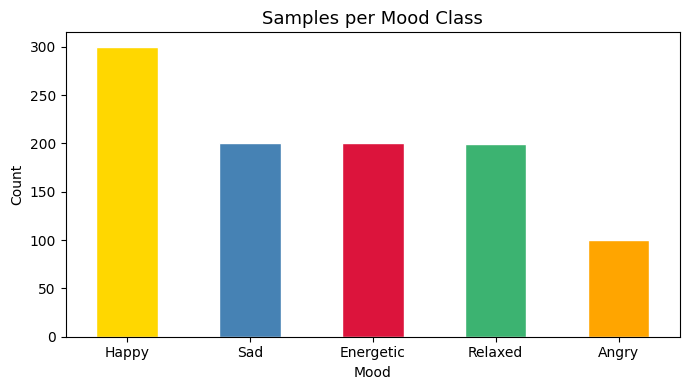

In [2]:
# Missing values?
print("Missing values per column:")
print(df.isnull().sum()[df.isnull().sum() > 0])
print("\nAll good!" if df.isnull().sum().sum() == 0 else "⚠️ Missing values found!")

# Data types
print(f"\nDtypes: {df.dtypes.value_counts().to_dict()}")

# Class balance
fig, ax = plt.subplots(figsize=(7, 4))
df['mood'].value_counts().plot(kind='bar', color=['gold','steelblue','crimson','mediumseagreen','orange'],
                                ax=ax, edgecolor='white')
ax.set_title('Samples per Mood Class', fontsize=13)
ax.set_xlabel('Mood')
ax.set_ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_28436\1576228730.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='mood', y=feat, palette=COLORS, ax=ax)
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_28436\1576228730.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='mood', y=feat, palette=COLORS, ax=ax)
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_28436\1576228730.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='mood', y=feat, palette=COLORS, ax=ax)
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_28436\1

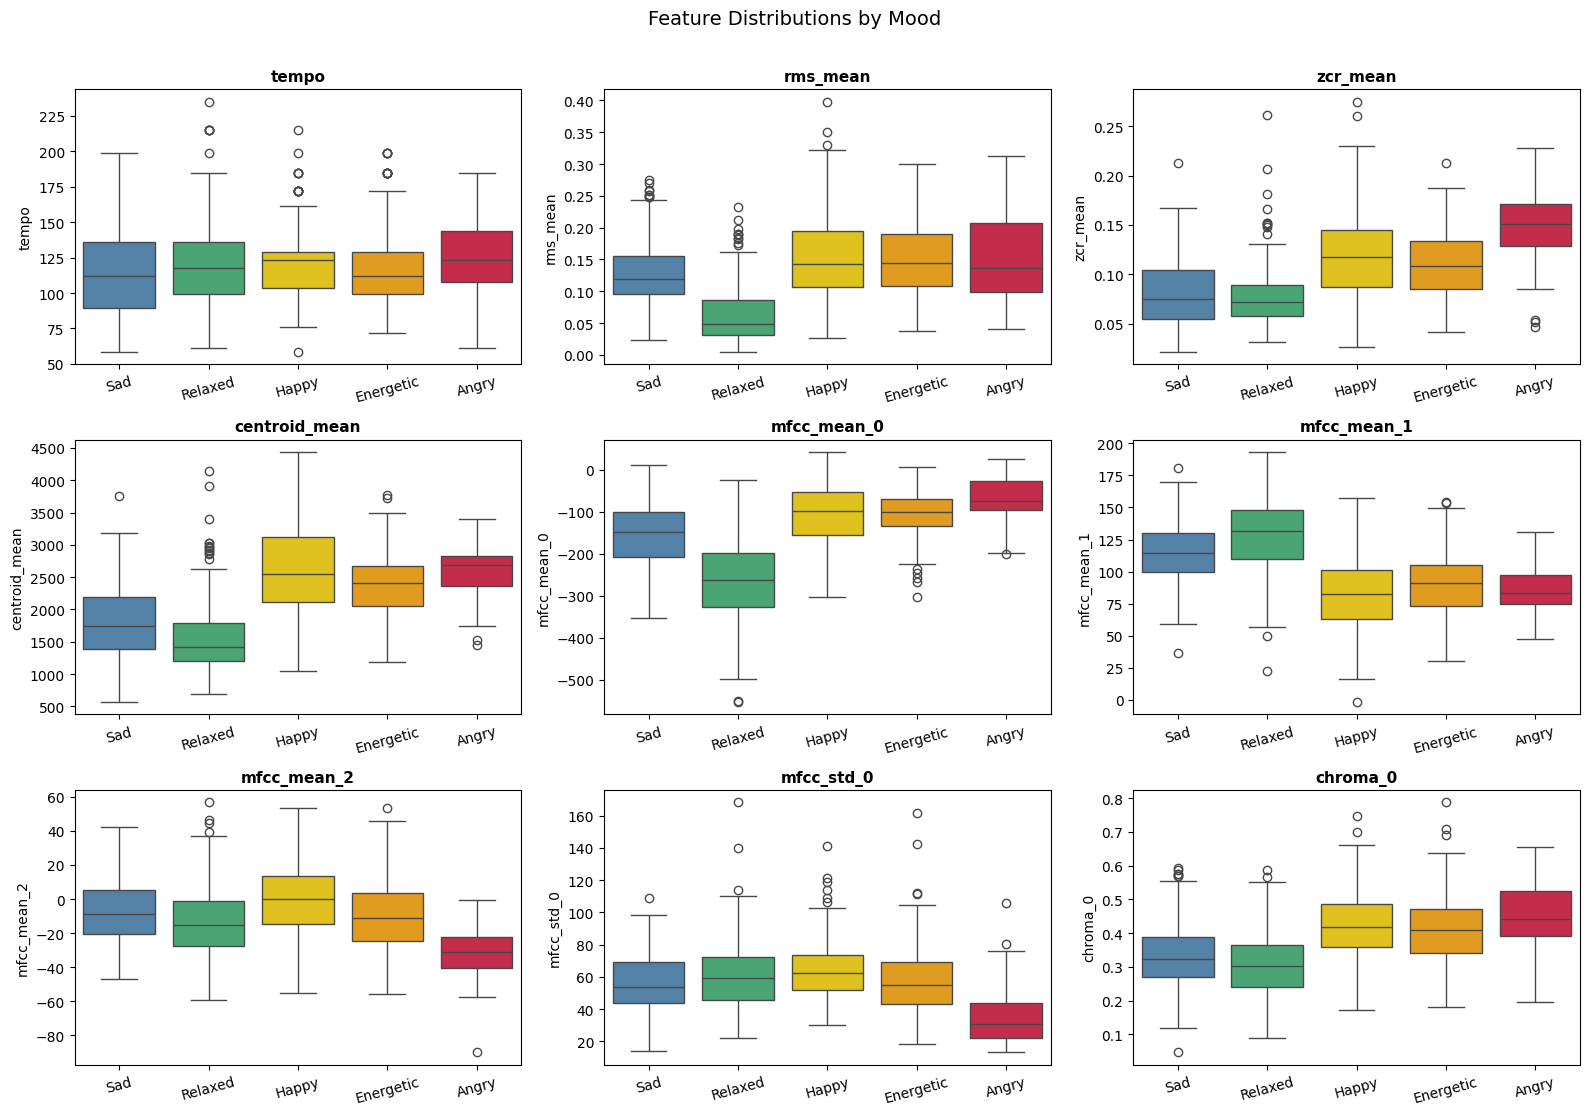

Saved → plots/eda_boxplots.png


In [3]:
COLORS = {
    'Happy':     'gold',
    'Sad':       'steelblue',
    'Angry':     'crimson',
    'Relaxed':   'mediumseagreen',
    'Energetic': 'orange',
}

features_to_plot = [
    'tempo', 'rms_mean', 'zcr_mean',
    'centroid_mean', 'mfcc_mean_0', 'mfcc_mean_1',
    'mfcc_mean_2', 'mfcc_std_0', 'chroma_0'
]

fig, axes = plt.subplots(3, 3, figsize=(16, 11))
for ax, feat in zip(axes.flat, features_to_plot):
    sns.boxplot(data=df, x='mood', y=feat, palette=COLORS, ax=ax)
    ax.set_title(feat, fontsize=11, fontweight='bold')
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=15)

plt.suptitle('Feature Distributions by Mood', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('../plots/eda_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved → plots/eda_boxplots.png")

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_28436\398756533.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='mood', y=feat, palette=COLORS, inner='box', ax=ax)
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_28436\398756533.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='mood', y=feat, palette=COLORS, inner='box', ax=ax)
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_28436\398756533.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='mood', y=feat, palette=COLORS, inner='box', ax=ax)


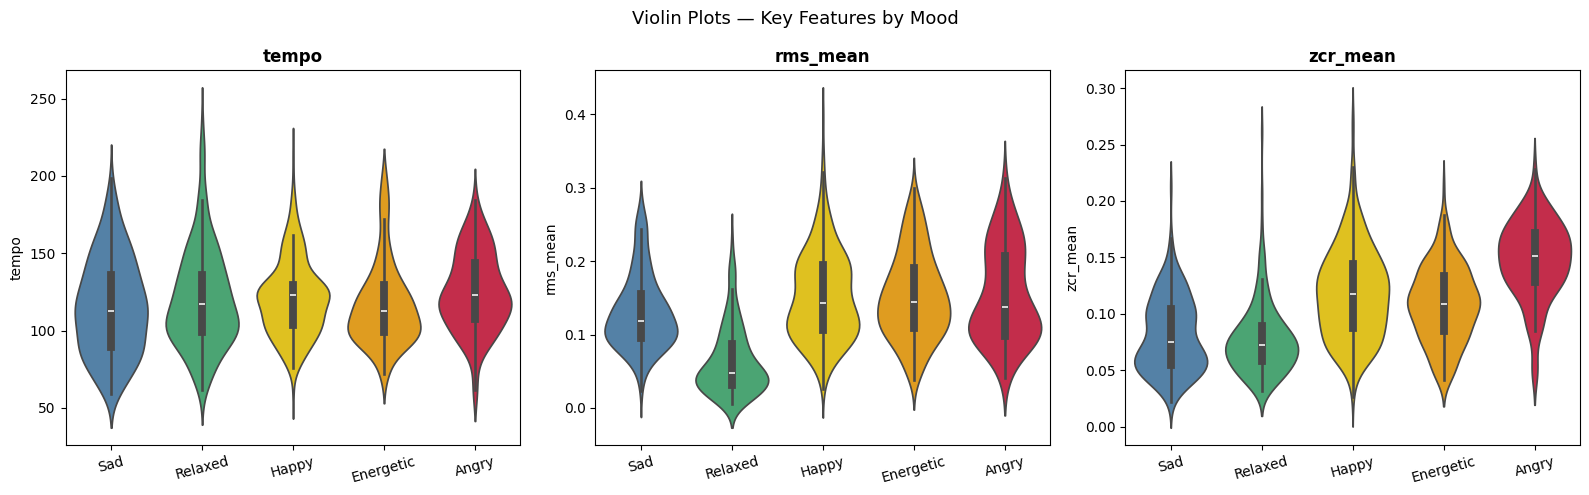

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, feat in zip(axes, ['tempo', 'rms_mean', 'zcr_mean']):
    sns.violinplot(data=df, x='mood', y=feat, palette=COLORS, inner='box', ax=ax)
    ax.set_title(feat, fontsize=12, fontweight='bold')
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=15)

plt.suptitle('Violin Plots — Key Features by Mood', fontsize=13)
plt.tight_layout()
plt.savefig('../plots/eda_violins.png', dpi=150, bbox_inches='tight')
plt.show()

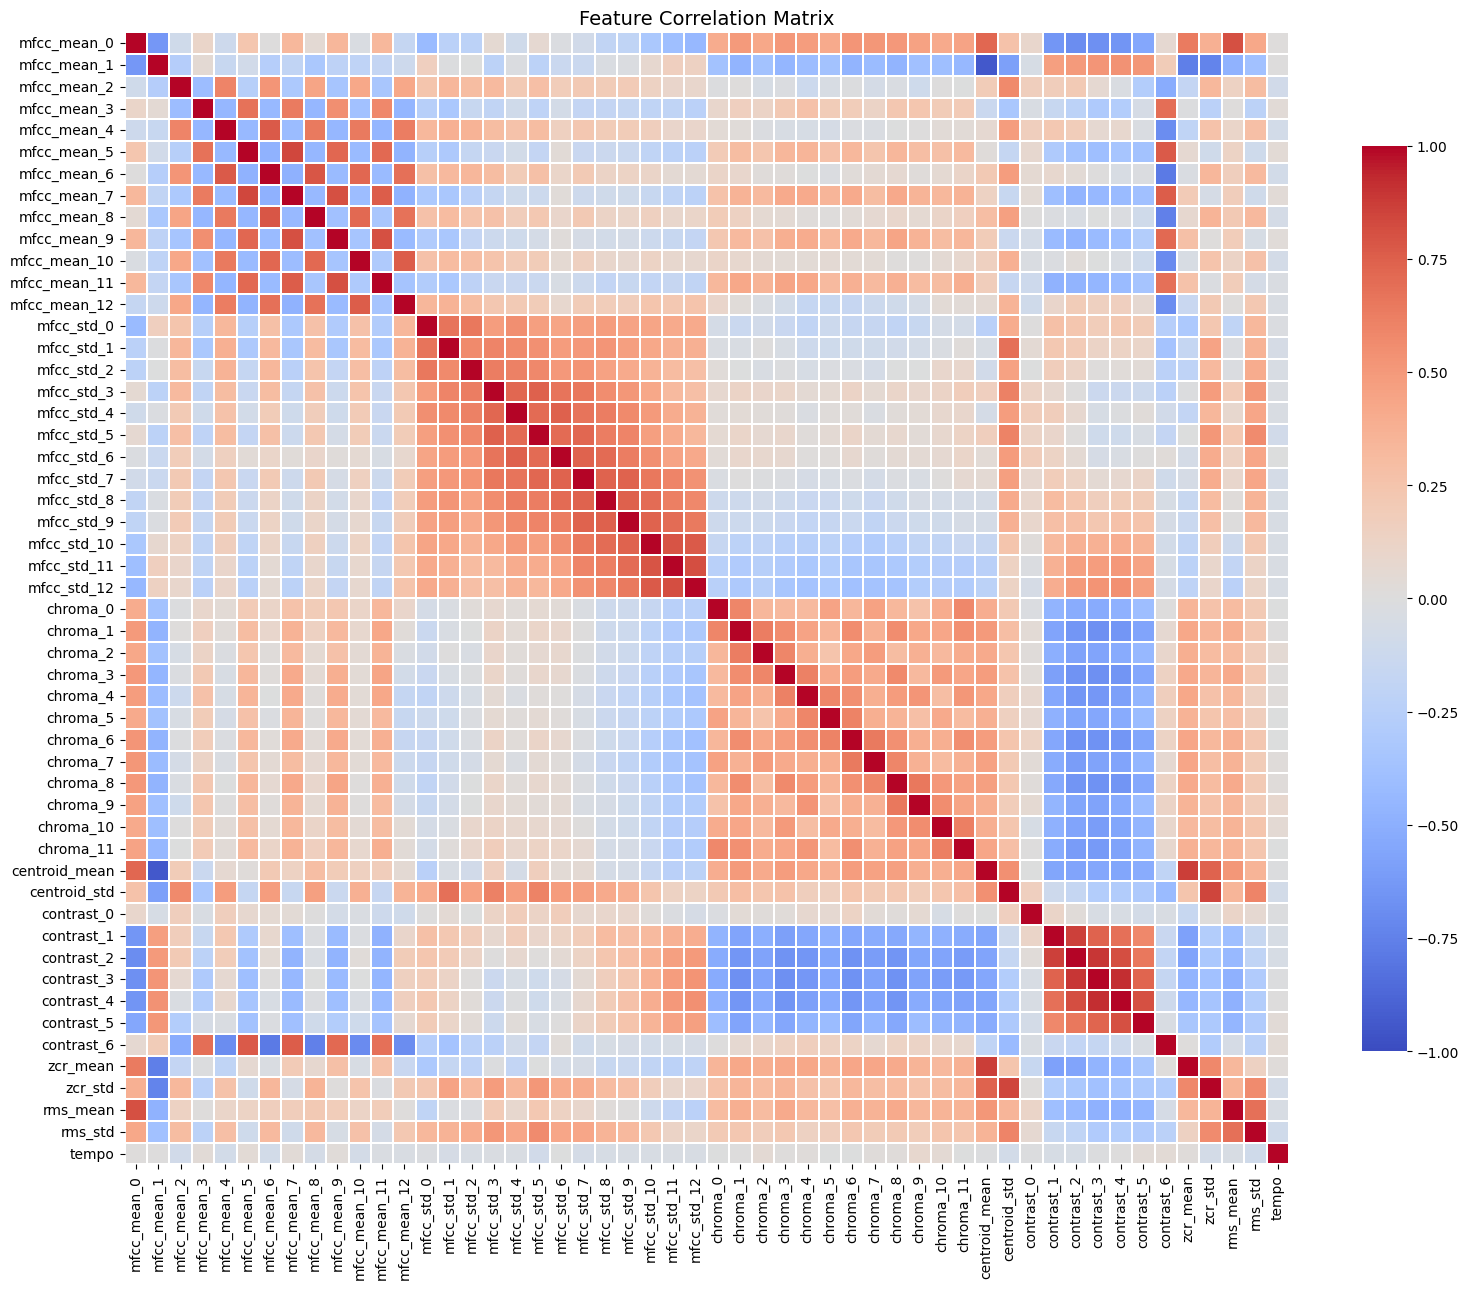

Saved → plots/eda_correlation.png

Top 10 most correlated pairs:
             feat_a         feat_b         r
1939  centroid_mean    mfcc_mean_1 -0.940166
88      mfcc_mean_1  centroid_mean -0.940166
2236     contrast_3     contrast_4  0.919768
2287     contrast_4     contrast_3  0.919768
2184     contrast_2     contrast_3  0.892124
2235     contrast_3     contrast_2  0.892124
2435       zcr_mean  centroid_mean  0.874674
1984  centroid_mean       zcr_mean  0.874674
2132     contrast_1     contrast_2  0.859949
2183     contrast_2     contrast_1  0.859949


In [5]:
meta_cols = ['filename', 'genre', 'mood']
feat_cols = [c for c in df.columns if c not in meta_cols]

corr = df[feat_cols].corr()

fig, ax = plt.subplots(figsize=(16, 13))
sns.heatmap(corr, cmap='coolwarm', center=0, vmin=-1, vmax=1,
            linewidths=0.1, ax=ax, cbar_kws={'shrink': 0.8})
ax.set_title('Feature Correlation Matrix', fontsize=14)
plt.tight_layout()
plt.savefig('../plots/eda_correlation.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved → plots/eda_correlation.png")

# Most correlated pairs (excluding diagonal)
corr_pairs = (corr.where(~np.eye(len(corr), dtype=bool))
                  .stack()
                  .reset_index())
corr_pairs.columns = ['feat_a', 'feat_b', 'r']
corr_pairs['abs_r'] = corr_pairs['r'].abs()
print("\nTop 10 most correlated pairs:")
print(corr_pairs.sort_values('abs_r', ascending=False).head(10)[['feat_a','feat_b','r']].to_string())

Top 20 most discriminative features (ANOVA F-score):
      feature    f_score       p_value
   contrast_3 339.866374 2.640983e-184
   contrast_4 337.187891 2.541971e-183
   contrast_2 226.518644 3.377535e-138
  mfcc_mean_0 194.566508 3.335062e-123
 centroid_std 165.776845 9.649999e-109
centroid_mean 141.696430  7.383344e-96
     chroma_8 141.415250  1.055121e-95
   contrast_5 141.017893  1.748251e-95
     chroma_1 137.520249  1.522520e-93
     chroma_6 131.872673  2.249085e-90
     chroma_4 131.485717  3.722792e-90
      zcr_std 125.666987  7.740815e-87
  mfcc_mean_1 124.550605  3.397740e-86
     chroma_3 116.160447  2.635203e-81
  mfcc_mean_3 113.667763  7.850740e-80
    chroma_11 112.162796  6.162448e-79
   contrast_1 103.093846  1.824848e-73
     chroma_9 101.961881  8.992757e-73
     zcr_mean  99.399262  3.389672e-71
  mfcc_mean_7  97.301119  6.749033e-70


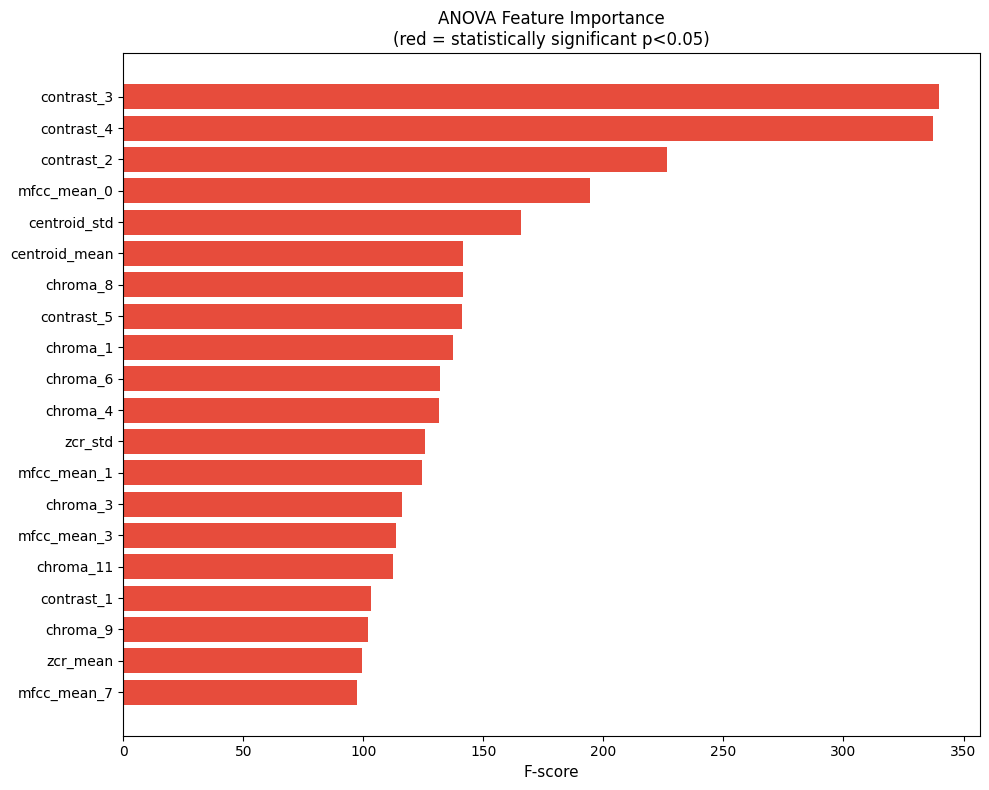

In [6]:
X = df[feat_cols].values
le = LabelEncoder()
y = le.fit_transform(df['mood'])

selector = SelectKBest(score_func=f_classif, k='all')
selector.fit(X, y)

importance_df = pd.DataFrame({
    'feature':  feat_cols,
    'f_score':  selector.scores_,
    'p_value':  selector.pvalues_
}).sort_values('f_score', ascending=False)

print("Top 20 most discriminative features (ANOVA F-score):")
print(importance_df.head(20).to_string(index=False))

# Plot
fig, ax = plt.subplots(figsize=(10, 8))
top20 = importance_df.head(20)
colors_bar = ['#E74C3C' if p < 0.05 else '#95A5A6' for p in top20['p_value']]
ax.barh(top20['feature'][::-1], top20['f_score'][::-1], color=colors_bar[::-1])
ax.set_xlabel('F-score', fontsize=11)
ax.set_title('ANOVA Feature Importance\n(red = statistically significant p<0.05)', fontsize=12)
plt.tight_layout()
plt.savefig('../plots/eda_anova.png', dpi=150, bbox_inches='tight')
plt.show()

Variance explained → PC1: 27.4%  PC2: 20.1%  Total: 47.5%


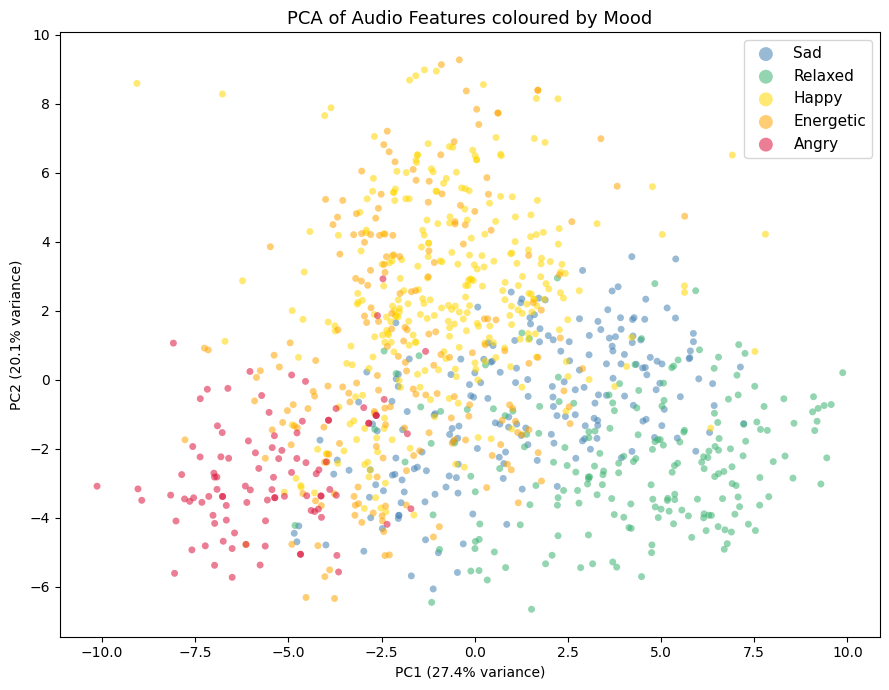

In [7]:
X_scaled = StandardScaler().fit_transform(df[feat_cols])

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

print(f"Variance explained → PC1: {pca.explained_variance_ratio_[0]:.1%}  "
      f"PC2: {pca.explained_variance_ratio_[1]:.1%}  "
      f"Total: {pca.explained_variance_ratio_.sum():.1%}")

fig, ax = plt.subplots(figsize=(9, 7))
for mood in df['mood'].unique():
    mask = df['mood'] == mood
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
               c=COLORS.get(mood, 'gray'), label=mood,
               alpha=0.55, s=25, edgecolors='none')

ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)")
ax.set_title('PCA of Audio Features coloured by Mood', fontsize=13)
ax.legend(markerscale=2, fontsize=11)
plt.tight_layout()
plt.savefig('../plots/eda_pca.png', dpi=150, bbox_inches='tight')
plt.show()

Running t-SNE... (takes ~30 seconds)


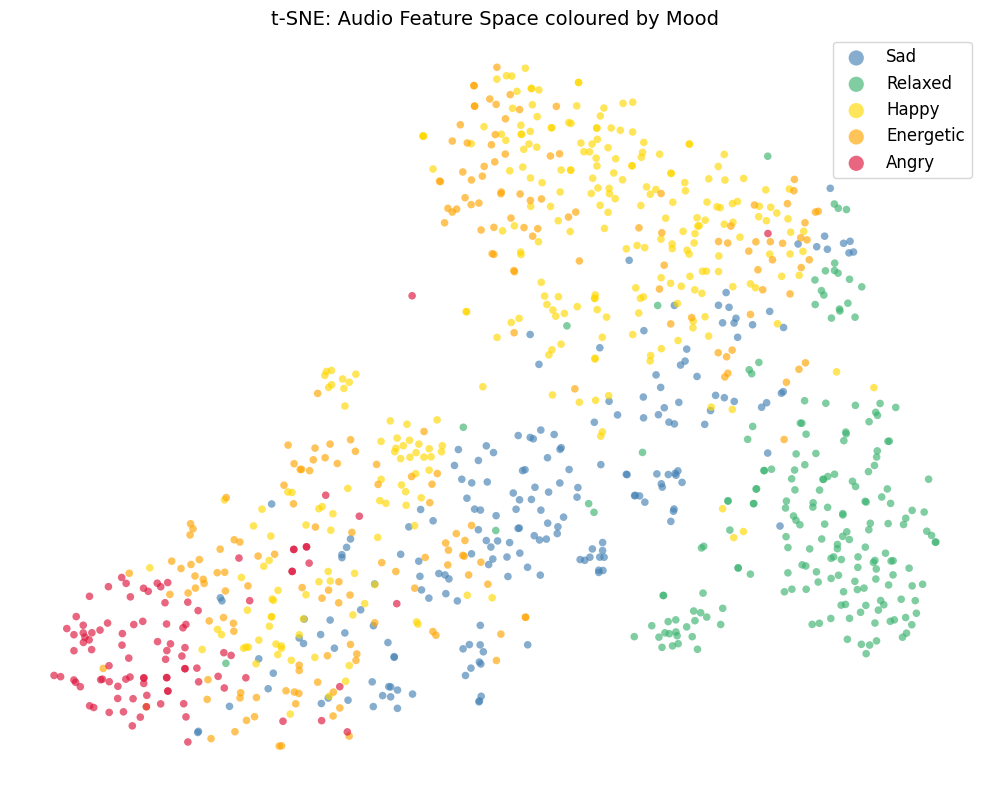

Saved → plots/eda_tsne.png

⬆️  THIS is the plot you present in your report and interview.


In [9]:
print("Running t-SNE... (takes ~30 seconds)")
tsne = TSNE(n_components=2, perplexity=30, max_iter=1000,
            random_state=42, learning_rate='auto', init='pca')
X_tsne = tsne.fit_transform(X_scaled)

fig, ax = plt.subplots(figsize=(10, 8))
for mood in df['mood'].unique():
    mask = df['mood'] == mood
    ax.scatter(X_tsne[mask, 0], X_tsne[mask, 1],
               c=COLORS.get(mood, 'gray'), label=mood,
               alpha=0.65, s=30, edgecolors='none')

ax.set_title('t-SNE: Audio Feature Space coloured by Mood', fontsize=14)
ax.legend(markerscale=2, fontsize=12)
ax.axis('off')   # axes have no meaning in t-SNE
plt.tight_layout()
plt.savefig('../plots/eda_tsne.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved → plots/eda_tsne.png")
print("\n⬆️  THIS is the plot you present in your report and interview.")

In [11]:
print("""
EDA Observations:
─────────────────────────────────────────────────────
1. Class balance   : moderately balanced
2. Strongest features (ANOVA top 3) : contrast_3, contrast_4, contrast_2
3. PCA variance explained           : 47.5%
4. t-SNE clusters                   : well separated 
5. Most confused pair               : Energitic and Angry
6. Any outliers spotted?            : no
─────────────────────────────────────────────────────
These become your EDA section in the report.
""")


EDA Observations:
─────────────────────────────────────────────────────
1. Class balance   : moderately balanced
2. Strongest features (ANOVA top 3) : contrast_3, contrast_4, contrast_2
3. PCA variance explained           : 47.5%
4. t-SNE clusters                   : well separated 
5. Most confused pair               : Energitic and Angry
6. Any outliers spotted?            : no
─────────────────────────────────────────────────────
These become your EDA section in the report.

